<h1 align="center">
Customer Lifetime Value (CLV) optimization </h1>


### 📌 Problem Statement

An e-commerce company notices that overall sales have stagnated, even though the number of new customers is increasing.
After analysis, the team discovers that many customers purchase only once, which lowers the average Customer Lifetime Value (CLV) and reduces long-term profitability.


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter, GammaGammaFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lifetimes.utils import summary_data_from_transaction_data


In [ ]:
# Data similation
data = {
    'customer_id': np.random.randint(1, 101, 500),
    'order_date': pd.date_range('2024-01-01', periods=500, freq='D'),
    'amount': np.random.uniform(20, 300, 500)
}
df = pd.DataFrame(data)



In [7]:
df.head()

,customer_id,order_date,amount
0,80,2024-01-01,236.373955
1,10,2024-01-02,269.601811
2,60,2024-01-03,293.266859
3,62,2024-01-04,188.481794
4,44,2024-01-05,87.439862


In [8]:
# Prepare Data for CLV Model


summary = summary_data_from_transaction_data(
    df, 
    customer_id_col='customer_id', 
    datetime_col='order_date', 
    monetary_value_col='amount', 
    observation_period_end=df['order_date'].max()
)
summary.head()


,frequency,recency,T,monetary_value
customer_id,,,,
1,3.0,165.0,268.0,98.667134
2,6.0,241.0,362.0,149.389930
3,3.0,351.0,442.0,228.668898
4,4.0,430.0,462.0,192.590290
5,1.0,39.0,107.0,216.390167


| **Column**         | **Meaning**                  | **Detailed Explanation**                                                                                                                                                      |
| ------------------ | ---------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **customer_id**    | Customer identifier          | A unique number that identifies each customer.                                                                                                                                |
| **frequency**      | Purchase frequency           | Number of **repeat purchases** made by the customer (the first purchase is not counted). Example: a value of `3` means the customer made **4 total purchases**.               |
| **recency**        | Recency (in days)            | The time (in days) between the **first purchase** and the **last purchase** during the observation period. A higher value means the customer stayed active for a longer time. |
| **T**              | Observation period (in days) | The total time (in days) between the **first purchase** and the **end of the observation window**. It represents how long the customer’s behavior was tracked.                |
| **monetary_value** | Average monetary value       | The **average amount spent per transaction** by the customer. Example: `98.66` means the customer spends about **$98.66 per purchase**.                                       |


In [9]:
# Fit CLV Model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])


<lifetimes.BetaGeoFitter: fitted with 100 subjects, a: 0.00, alpha: 293.33, b: 0.00, r: 2.88>

In [14]:
#Gamma-Gamma for monetary value
# Keep only rows with positive monetary value
summary_positive = summary[summary['monetary_value'] > 0]

# Fit the Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary_positive['frequency'], summary_positive['monetary_value'])

# Calculate  expected average lifetime value
summary['expected_average_lifetime_value'] = ggf.conditional_expected_average_profit(summary['frequency'], summary['monetary_value'])


In [27]:
# Predict Customer Lifetime Value
summary['pred_purchases_6m'] = bgf.predict(180, summary['frequency'], summary['recency'], summary['T'])
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf, summary['frequency'], summary['recency'], summary['T'], summary['monetary_value'], time=6, freq='D', discount_rate=0.01
)
# Sort customers by predicted CLV and select top 100
summary.sort_values('predicted_clv', ascending=False).head(10)

c:\Users\timot\miniconda3\envs\Final_version_of_chatbot\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\timot\miniconda3\envs\Final_version_of_chatbot\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,expected_average_lifetime_value,pred_purchases_6m,predicted_clv,CLV_segment
customer_id,,,,,,,,
26,6.0,251.0,308.0,250.810447,257.109937,2.658588,660.248983,VIP
96,12.0,453.0,460.0,155.390041,157.450719,3.555794,540.778220,VIP
94,8.0,298.0,328.0,167.868138,171.184275,3.152411,521.248221,VIP
58,7.0,397.0,471.0,220.458822,225.261755,2.327122,506.342664,VIP
91,6.0,297.0,324.0,180.363847,185.089267,2.589682,462.983636,VIP
78,4.0,276.0,377.0,234.286172,243.282078,1.847881,434.232236,VIP
97,7.0,412.0,449.0,182.777862,186.861421,2.396089,432.474559,VIP
5,1.0,39.0,107.0,216.390167,253.745974,1.745286,427.763486,VIP
11,5.0,314.0,383.0,198.447511,204.630523,2.097629,414.607420,VIP


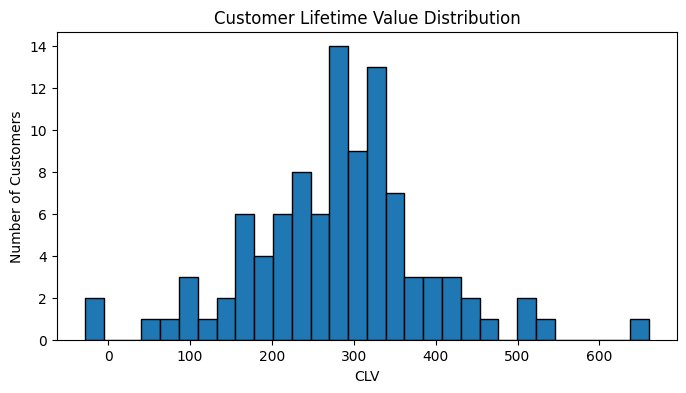

In [ ]:
# Data visualization

plt.figure(figsize=(8,4))
plt.hist(summary['predicted_clv'], bins=30, edgecolor='k')
plt.title('Customer Lifetime Value Distribution')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.show()



In [ ]:

# Actionable Insights
summary['CLV_segment'] = pd.qcut(summary['predicted_clv'], 4, labels=['Low', 'Medium', 'High', 'VIP'])

summary.groupby('CLV_segment')['predicted_clv'].mean()

CLV_segment
Low       143.268253
Medium    259.323815
High      310.315826
VIP       409.580817
Name: predicted_clv, dtype: float64

In [23]:
summary.groupby('CLV_segment')['predicted_clv'].count()


CLV_segment
Low       25
Medium    25
High      24
VIP       25
Name: predicted_clv, dtype: int64

In [24]:
summary.groupby('CLV_segment')['predicted_clv'].std()

CLV_segment
Low       68.461281
Medium    21.217245
High      15.482616
VIP       78.392329
Name: predicted_clv, dtype: float64

In [29]:
%pip install nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate metrics
total_count = len(df)
total_sum = df['amount'].sum()
mean_amount = df['amount'].mean()

# Create subplots: 1 row, 3 columns
fig = make_subplots(rows=1, cols=3, 
                   specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}]])

# Add pie charts
fig.add_trace(go.Pie(labels=['Count'], values=[total_count], name="Count"), 1, 1)
fig.add_trace(go.Pie(labels=['Total Amount'], values=[total_sum], name="Sum"), 1, 2)
fig.add_trace(go.Pie(labels=['Mean Amount'], values=[mean_amount], name="Mean"), 1, 3)

# Update layout
fig.update_traces(hole=.4, hoverinfo="label+value+percent+name")
fig.update_layout(
    title_text="Transaction Metrics Overview",
    annotations=[dict(text='Count', x=0.1, y=0.5, font_size=14, showarrow=False),
                 dict(text='Sum', x=0.5, y=0.5, font_size=14, showarrow=False),
                 dict(text='Mean', x=0.9, y=0.5, font_size=14, showarrow=False)]
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

- Target High/VIP segments with retention and upsell campaigns.

- Use Low CLV insights to improve onboarding or reduce churn.

### ✅ Proposed Solution

Increase the average CLV per customer by 25% within 6 months through CLV prediction and behavioral segmentation.

✅ Expected Result
- Higher customer retention rate
- Increased average revenue per user (ARPU)
- Lower CAC-to-CLV ratio → stronger long-term profitability

# Solution Steps:

## Data Collection & Preparation

Gather purchase history (date, amount, customer_id).

Clean and transform data to create key metrics: frequency, recency, and monetary value.

## CLV Modeling

Use the BG/NBD + Gamma-Gamma model (via the lifetimes library) to predict:

The expected number of future purchases per customer.

The total expected value (monetary CLV).

## Customer Segmentation

Segment customers based on predicted CLV:

-🔴 Low CLV → reactivation campaigns

-🟡 Medium CLV → loyalty programs

-🟢 High CLV → premium offers, cross-sell, VIP care

## Targeted Marketing Actions

- Personalized emails for each segment

- Smart discounts for at-risk (churn) customers

- Product recommendations based on purchase patterns

## Monitoring & Continuous Optimization

Build a dashboard (Streamlit, Power BI, or Dash) to track:

- Average CLV by segment

- Repeat purchase rate

- ROI of marketing campaigns